# Recession Prediction Using Machine Learning
## DATA.110.HY1 — Introduction to Python Programming for Machine Learning
### Spring A 2026

**Project Topic:** Economic Recession Prediction Using Macroeconomic Indicators  
**Dataset:** FRED-MD (Federal Reserve Bank of St. Louis) + USREC (NBER Recession Indicator)  
**Task Type:** Binary Classification (Recession = 1, Expansion = 0)  
**Forecast Horizon:** 3 months ahead  
**Models:** Logistic Regression, Random Forest, Gradient Boosting, SVM

---


## 0. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

# Plot settings
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
})
COLORS = {'expansion': '#2196F3', 'recession': '#F44336',
          'primary': '#1565C0', 'recession_shade': '#FFCDD2'}
print("All libraries loaded successfully!")

All libraries loaded successfully!


## 1. Data Loading & Preparation

We use:
- **FRED-MD** `final_combined_dataset.csv` — 143 monthly macroeconomic series, 1959–2024
- **USREC** — NBER-based binary recession indicator (target variable)

The FRED-MD dataset includes a `Transform:` row with codes indicating the correct stationarity transformation for each series.


In [2]:
# ── Load FRED-MD ──────────────────────────────────────────────────
df_raw = pd.read_csv('final_combined_dataset.csv', low_memory=False)

# Extract transformation codes
transform_row = df_raw[df_raw['sasdate'] == 'Transform:'].iloc[0]
tcodes = {}
for col in df_raw.columns:
    try:
        tcodes[col] = float(transform_row[col])
    except:
        pass

# Keep combined_dataset rows only, deduplicate on date
df_main = df_raw[df_raw['source_file'] == 'combined_dataset.csv'].copy()
df_main = df_main[df_main['sasdate'] != 'Transform:']
df_main = df_main.drop_duplicates(subset='sasdate', keep='first').reset_index(drop=True)
df_main['sasdate'] = pd.to_datetime(df_main['sasdate'], format='%m/%d/%Y')
df_main = df_main.set_index('sasdate').sort_index()
df_main.drop(columns=['source_file'], inplace=True, errors='ignore')
df_main = df_main.apply(pd.to_numeric, errors='coerce')

print(f"FRED-MD: {df_main.shape[0]} months × {df_main.shape[1]} series")
print(f"Date range: {df_main.index[0].date()} → {df_main.index[-1].date()}")

FRED-MD: 791 months × 143 series
Date range: 1959-01-01 → 2024-11-01


In [3]:
# ── Load USREC ────────────────────────────────────────────────────
usrec = pd.read_csv('USREC.csv')
usrec['observation_date'] = pd.to_datetime(usrec['observation_date'])
usrec = usrec.set_index('observation_date').sort_index()
usrec = usrec[usrec.index >= df_main.index[0]]

print(f"USREC: {len(usrec)} months")
print(f"Recession months: {usrec['USREC'].sum()} ({usrec['USREC'].mean()*100:.1f}%)")
print(f"Expansion months: {(usrec['USREC']==0).sum()} ({(usrec['USREC']==0).mean()*100:.1f}%)")

# ── Merge ──────────────────────────────────────────────────────────
df = df_main.merge(usrec, left_index=True, right_index=True, how='inner')
print(f"\nMerged dataset: {df.shape[0]} months × {df.shape[1]} columns")

USREC: 807 months
Recession months: 95 (11.8%)
Expansion months: 712 (88.2%)

Merged dataset: 791 months × 144 columns


## 2. Stationarity Transformations

FRED-MD provides transformation codes (tcode) for each series:
| Code | Transformation |
|------|---------------|
| 1 | No transformation |
| 2 | First difference (Δx) |
| 3 | Second difference (Δ²x) |
| 4 | Log (ln x) |
| 5 | Log first difference (Δ ln x ≈ growth rate) |
| 6 | Log second difference (Δ² ln x) |
| 7 | Percentage change |

Outliers are removed using the McCracken & Ng (2016) rule: observations deviating from the median by more than 10× IQR are treated as missing.


In [4]:
def apply_tcode(series, code):
    s = series.copy().astype(float)
    if code == 1:   return s
    elif code == 2: return s.diff()
    elif code == 3: return s.diff().diff()
    elif code == 4: return np.log(s.clip(lower=1e-10))
    elif code == 5: return np.log(s.clip(lower=1e-10)).diff()
    elif code == 6: return np.log(s.clip(lower=1e-10)).diff().diff()
    elif code == 7: return s.pct_change()
    return s

feature_cols = [c for c in df.columns if c != 'USREC']
df_transformed = pd.DataFrame(index=df.index)
for col in feature_cols:
    df_transformed[col] = apply_tcode(df[col], tcodes.get(col, 1))
df_transformed['USREC'] = df['USREC'].values

# Outlier removal (10×IQR rule)
df_clean = df_transformed.copy()
for col in feature_cols:
    s = df_clean[col]
    iqr = s.quantile(0.75) - s.quantile(0.25)
    lower, upper = s.median() - 10*iqr, s.median() + 10*iqr
    df_clean.loc[(s < lower) | (s > upper), col] = np.nan

# Drop first 2 rows (lost to differencing), fill NaN
df_clean = df_clean.iloc[2:].ffill().bfill().fillna(0)
print(f"Clean transformed dataset: {df_clean.shape}")
print(f"Recession months: {df_clean['USREC'].sum()} ({df_clean['USREC'].mean()*100:.1f}%)")

Clean transformed dataset: (789, 144)
Recession months: 95 (12.0%)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution

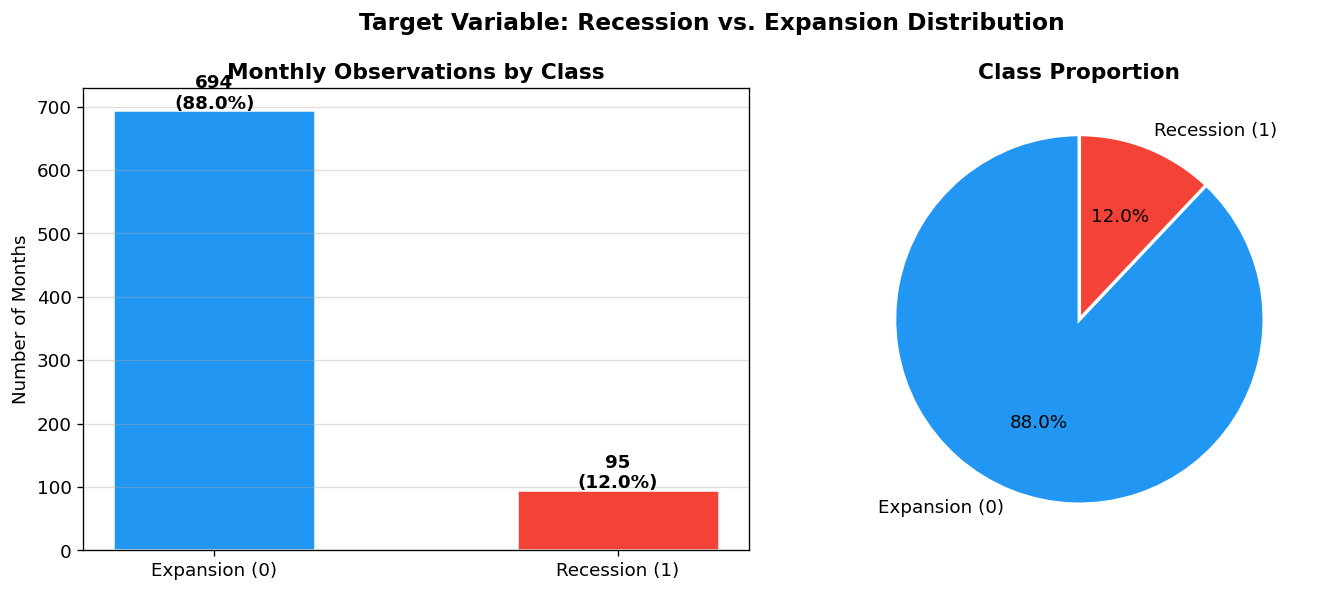

Class imbalance ratio: 7.3:1 (Expansion:Recession)


In [5]:
# Get NBER recession periods for shading
rec_idx = df_clean['USREC']
recession_periods = []
in_rec, start = False, None
for date, val in rec_idx.items():
    if val == 1 and not in_rec:
        in_rec = True; start = date
    elif val == 0 and in_rec:
        in_rec = False; recession_periods.append((start, date))

# Class distribution plot
target = df_clean['USREC']
counts = target.value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: Recession vs. Expansion Distribution', fontsize=14, fontweight='bold')

labels = ['Expansion (0)', 'Recession (1)']
bars = axes[0].bar(labels, counts.values,
                   color=[COLORS['expansion'], COLORS['recession']],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, c in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{c}\n({c/len(target)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Monthly Observations by Class', fontweight='bold')
axes[0].set_ylabel('Number of Months')
axes[0].grid(axis='y', alpha=0.4)

axes[1].pie(counts.values, labels=labels,
            colors=[COLORS['expansion'], COLORS['recession']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: {counts[0]/counts[1]:.1f}:1 (Expansion:Recession)")

### 3.2 Key Economic Indicators with Recession Shading

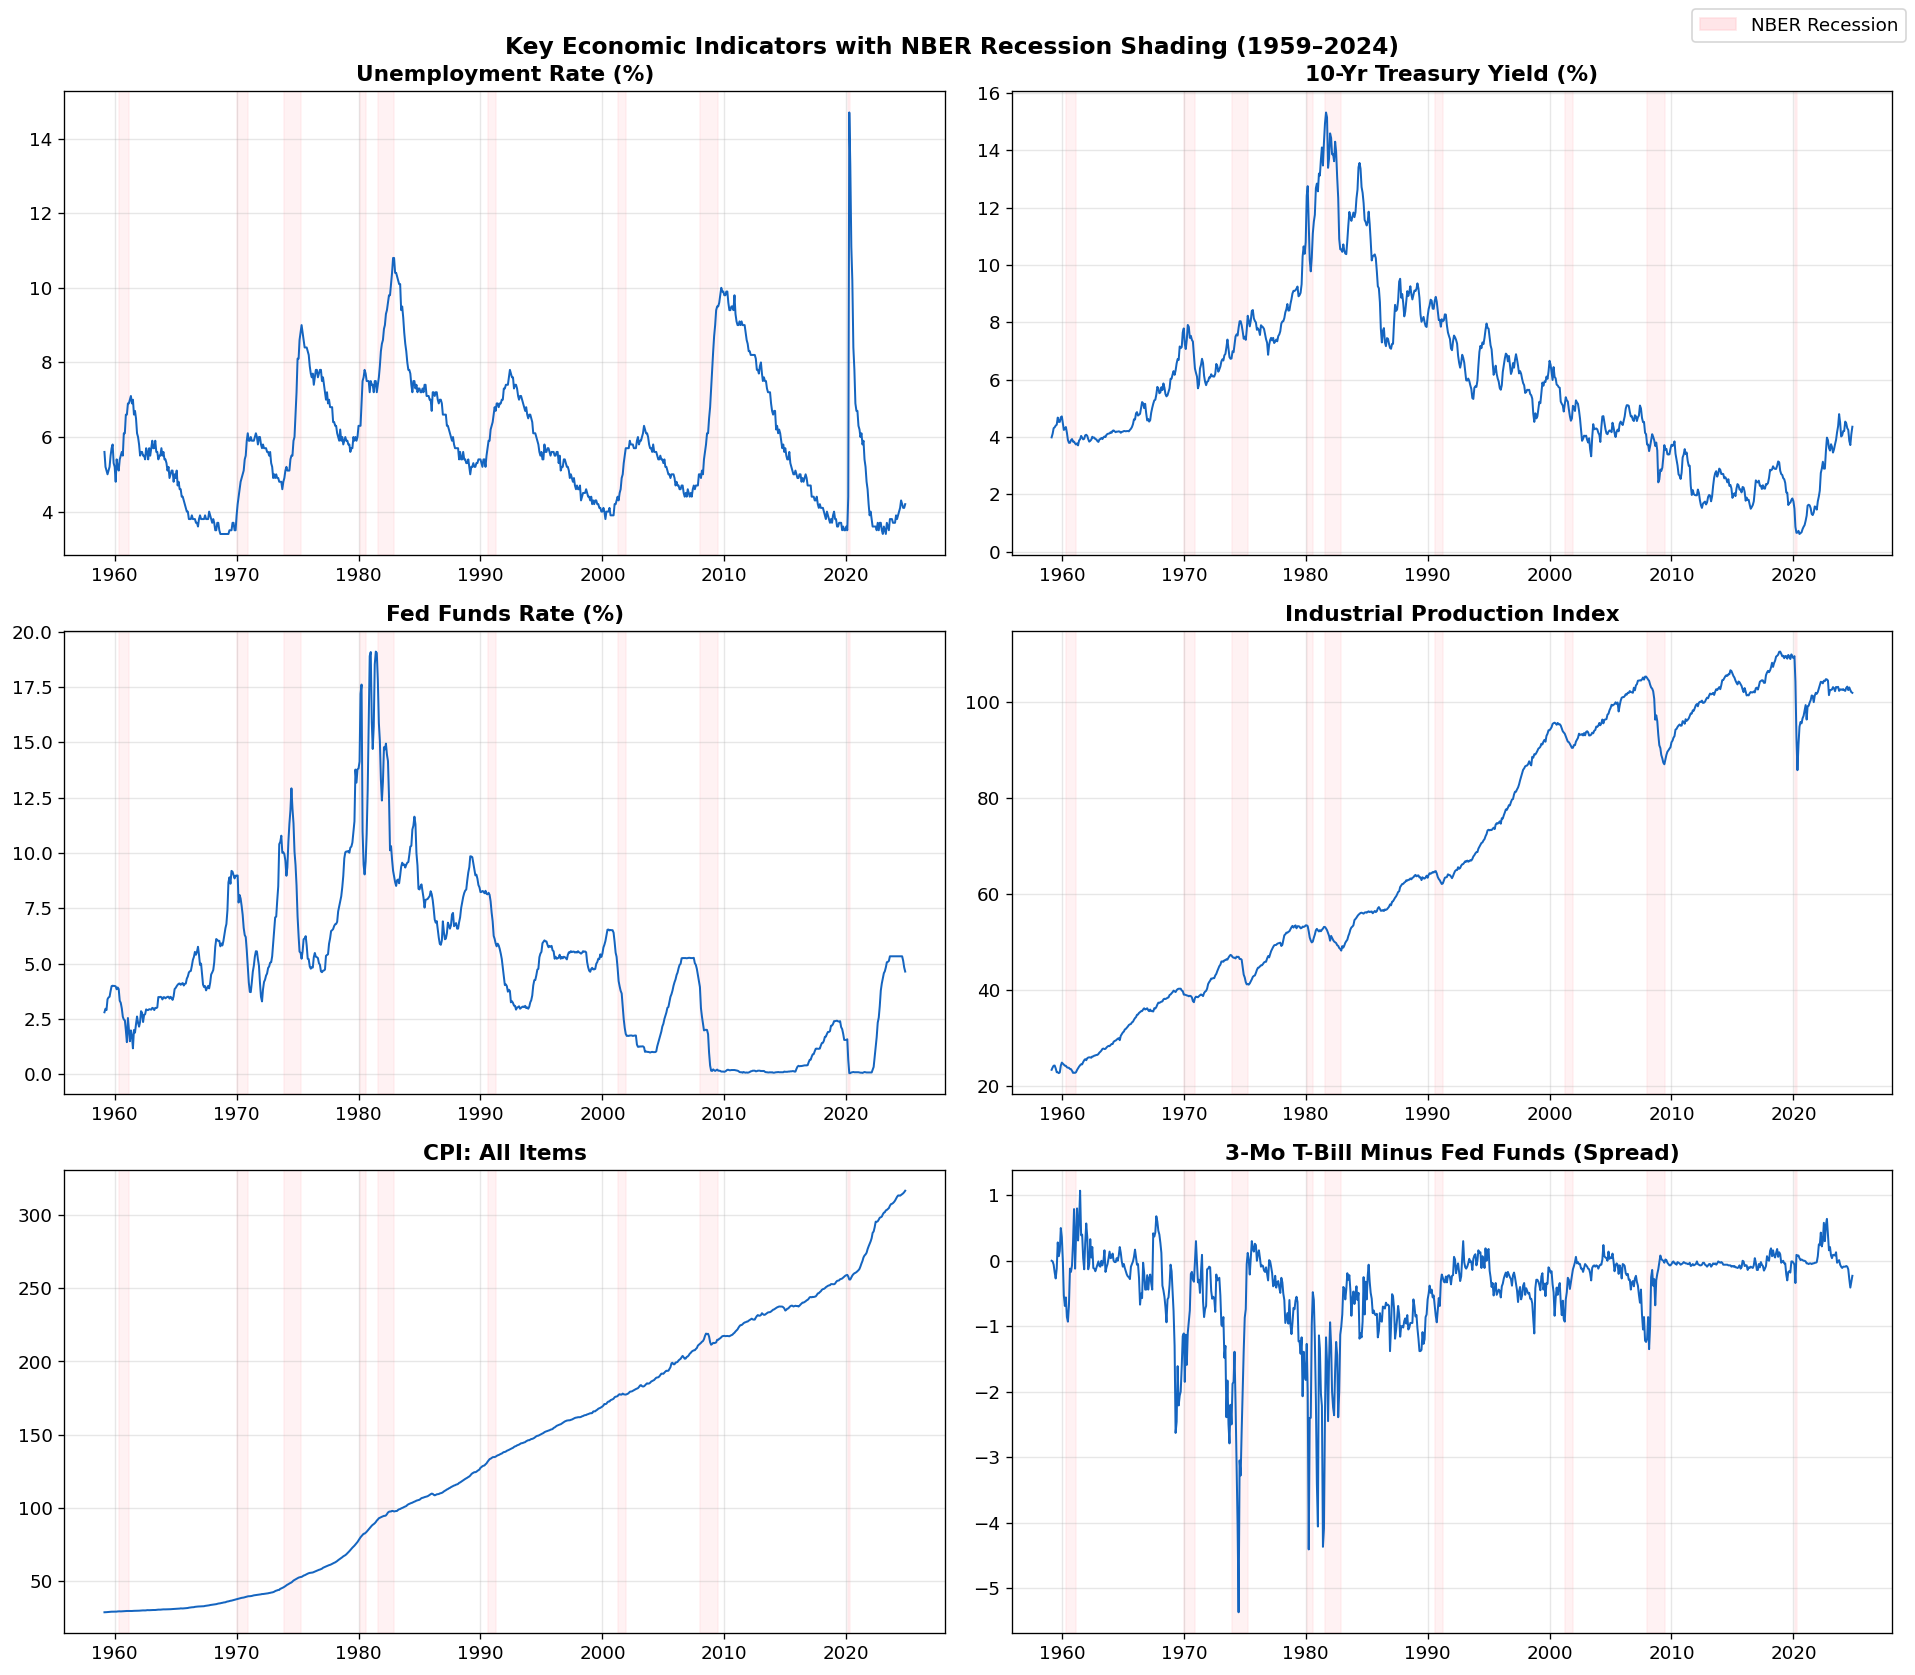

In [6]:
key_features = ['UNRATE', 'GS10', 'FEDFUNDS', 'INDPRO', 'CPIAUCSL', 'TB3SMFFM']
key_labels = ['Unemployment Rate (%)', '10-Yr Treasury Yield (%)',
              'Fed Funds Rate (%)', 'Industrial Production Index',
              'CPI: All Items', '3-Mo T-Bill Minus Fed Funds (Spread)']
raw = df[key_features].reindex(df_clean.index)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Key Economic Indicators with NBER Recession Shading (1959–2024)',
             fontsize=14, fontweight='bold')
for ax, feat, lab in zip(axes.flatten(), key_features, key_labels):
    ax.plot(raw.index, raw[feat], color=COLORS['primary'], linewidth=1.2)
    for s, e in recession_periods:
        ax.axvspan(s, e, alpha=0.25, color=COLORS['recession_shade'])
    ax.set_title(lab, fontweight='bold')
    ax.grid(alpha=0.3)
rec_patch = mpatches.Patch(color=COLORS['recession_shade'], alpha=0.5, label='NBER Recession')
fig.legend(handles=[rec_patch], labels=['NBER Recession'], loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

### 3.3 Descriptive Statistics

In [7]:
feat_cols = [c for c in df_clean.columns if c != 'USREC']
desc = df_clean[feat_cols].describe().T
desc['skewness'] = df_clean[feat_cols].skew()
desc['kurtosis'] = df_clean[feat_cols].kurt()
display_cols = ['mean', 'std', 'min', '50%', 'max', 'skewness', 'kurtosis']
desc_display = desc[display_cols].round(4)
desc_display.columns = ['Mean', 'Std Dev', 'Min', 'Median', 'Max', 'Skewness', 'Kurtosis']
print(f"Descriptive statistics for {len(desc_display)} features:")
print(desc_display.head(20).to_string())

Descriptive statistics for 143 features:
                   Mean   Std Dev       Min  Median       Max  Skewness  Kurtosis
RPI              0.0025    0.0057   -0.0328  0.0027    0.0405   -0.1756   13.5924
W875RX1          0.0026    0.0055   -0.0351  0.0028    0.0401    0.0634   15.5872
DPCERA3M086SBEA  0.0028    0.0058   -0.0254  0.0026    0.0569    1.4452   14.5442
CMRMTSPLx        0.0023    0.0112   -0.0525  0.0021    0.0738    0.1592    3.8503
RETAILx          0.0044    0.0141   -0.0883  0.0047    0.1069   -0.3966   13.3342
INDPRO           0.0020    0.0092   -0.0757  0.0023    0.0601   -1.0364   14.1935
IPFPNSS          0.0019    0.0085   -0.0591  0.0024    0.0660   -0.5470   11.7678
IPFINAL          0.0020    0.0094   -0.0639  0.0022    0.0787   -0.2815   12.8024
IPCONGD          0.0015    0.0099   -0.0625  0.0015    0.0768    0.0083    9.0165
IPDCONGD         0.0019    0.0257   -0.1911  0.0025    0.1506   -0.7834   12.9309
IPNCONGD         0.0012    0.0079   -0.0568  0.0015    0.

Group,Some Important Columns,What it measures

Output & Income,"RPI, INDPRO, IPFINAL, CUMFNS","Real Personal Income, Industrial Production, Capacity Utilization — how much the economy is producing"

Labor Market,"UNRATE, PAYEMS, USGOOD, MANEMP, CLAIMSx","Unemployment Rate, Total Non-farm Payrolls, Goods-producing jobs, Initial Jobless Claims — job market health"

Housing,"HOUST, PERMIT","Housing Starts, Building Permits — how many new houses are being built"

Consumption & Orders,"RETAILx, CMRMTSPLx","Retail Sales, Manufacturing orders — how much people and businesses are spending/buying"

Money & Credit,"M1SL, M2SL, BUSLOANS, CONSPI","Money supply (M1, M2), Bank loans, Consumer credit — how much money is flowing"

Interest Rates & Yield Curve,"FEDFUNDS, TB3MS, GS10, TB3SMFFM, T10YFFM","Federal Funds Rate, Treasury yields, Yield spreads — very important for recession prediction"

Prices & Inflation,"CPIAUCSL, PPI, OILPRICEx","Consumer Price Index, Producer Price Index, Oil prices — inflation level"

Stock Market,"S&P 500, S&P div yield, S&P PE ratio",Stock market performance

Others,"VXOCLSx (Volatility), NAPM (ISM PMI), etc.","Business surveys, market fear index"

### 3.4 Correlation Heatmap

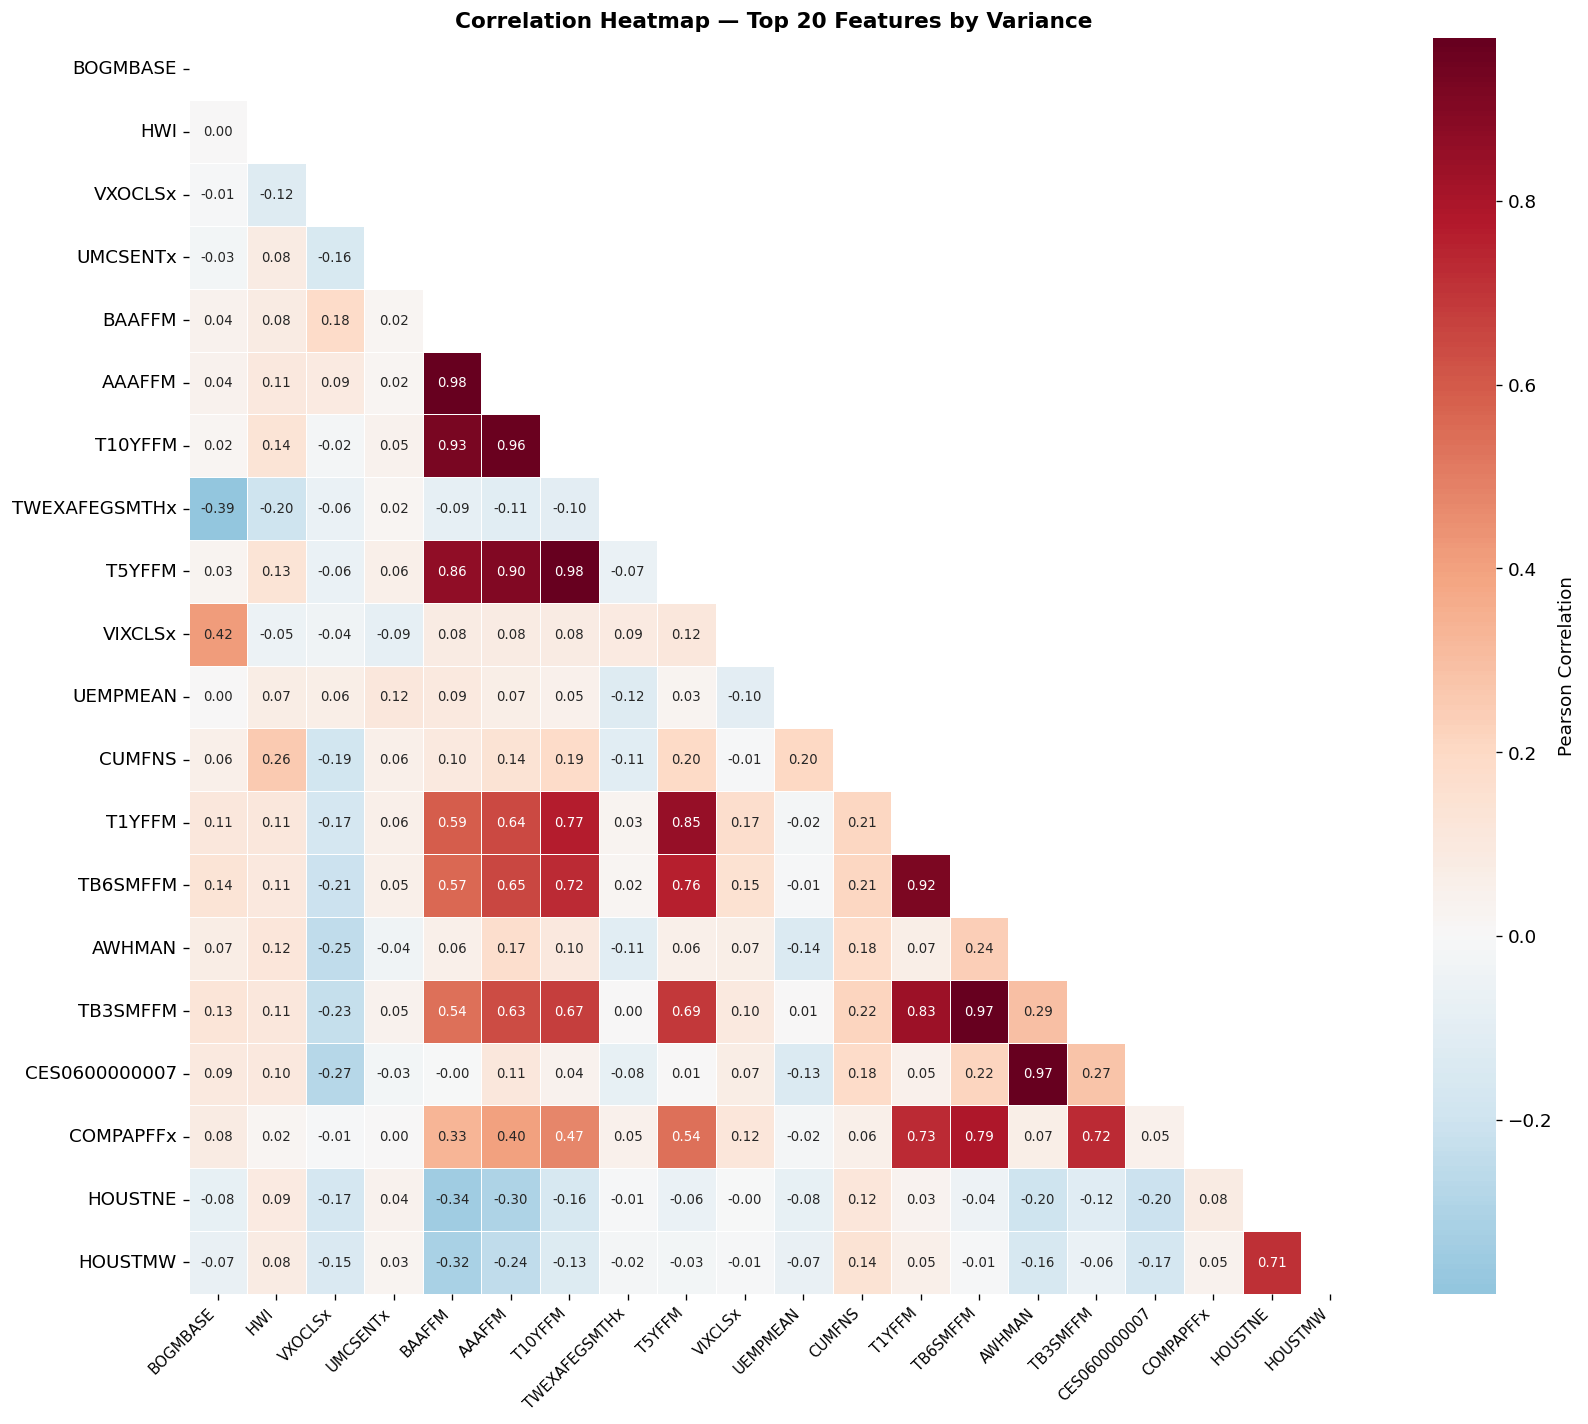

In [8]:
top20 = df_clean[feat_cols].var().nlargest(20).index.tolist()
corr = df_clean[top20].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Heatmap — Top 20 Features by Variance', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

### 3.5 Box Plots: Recession vs. Expansion

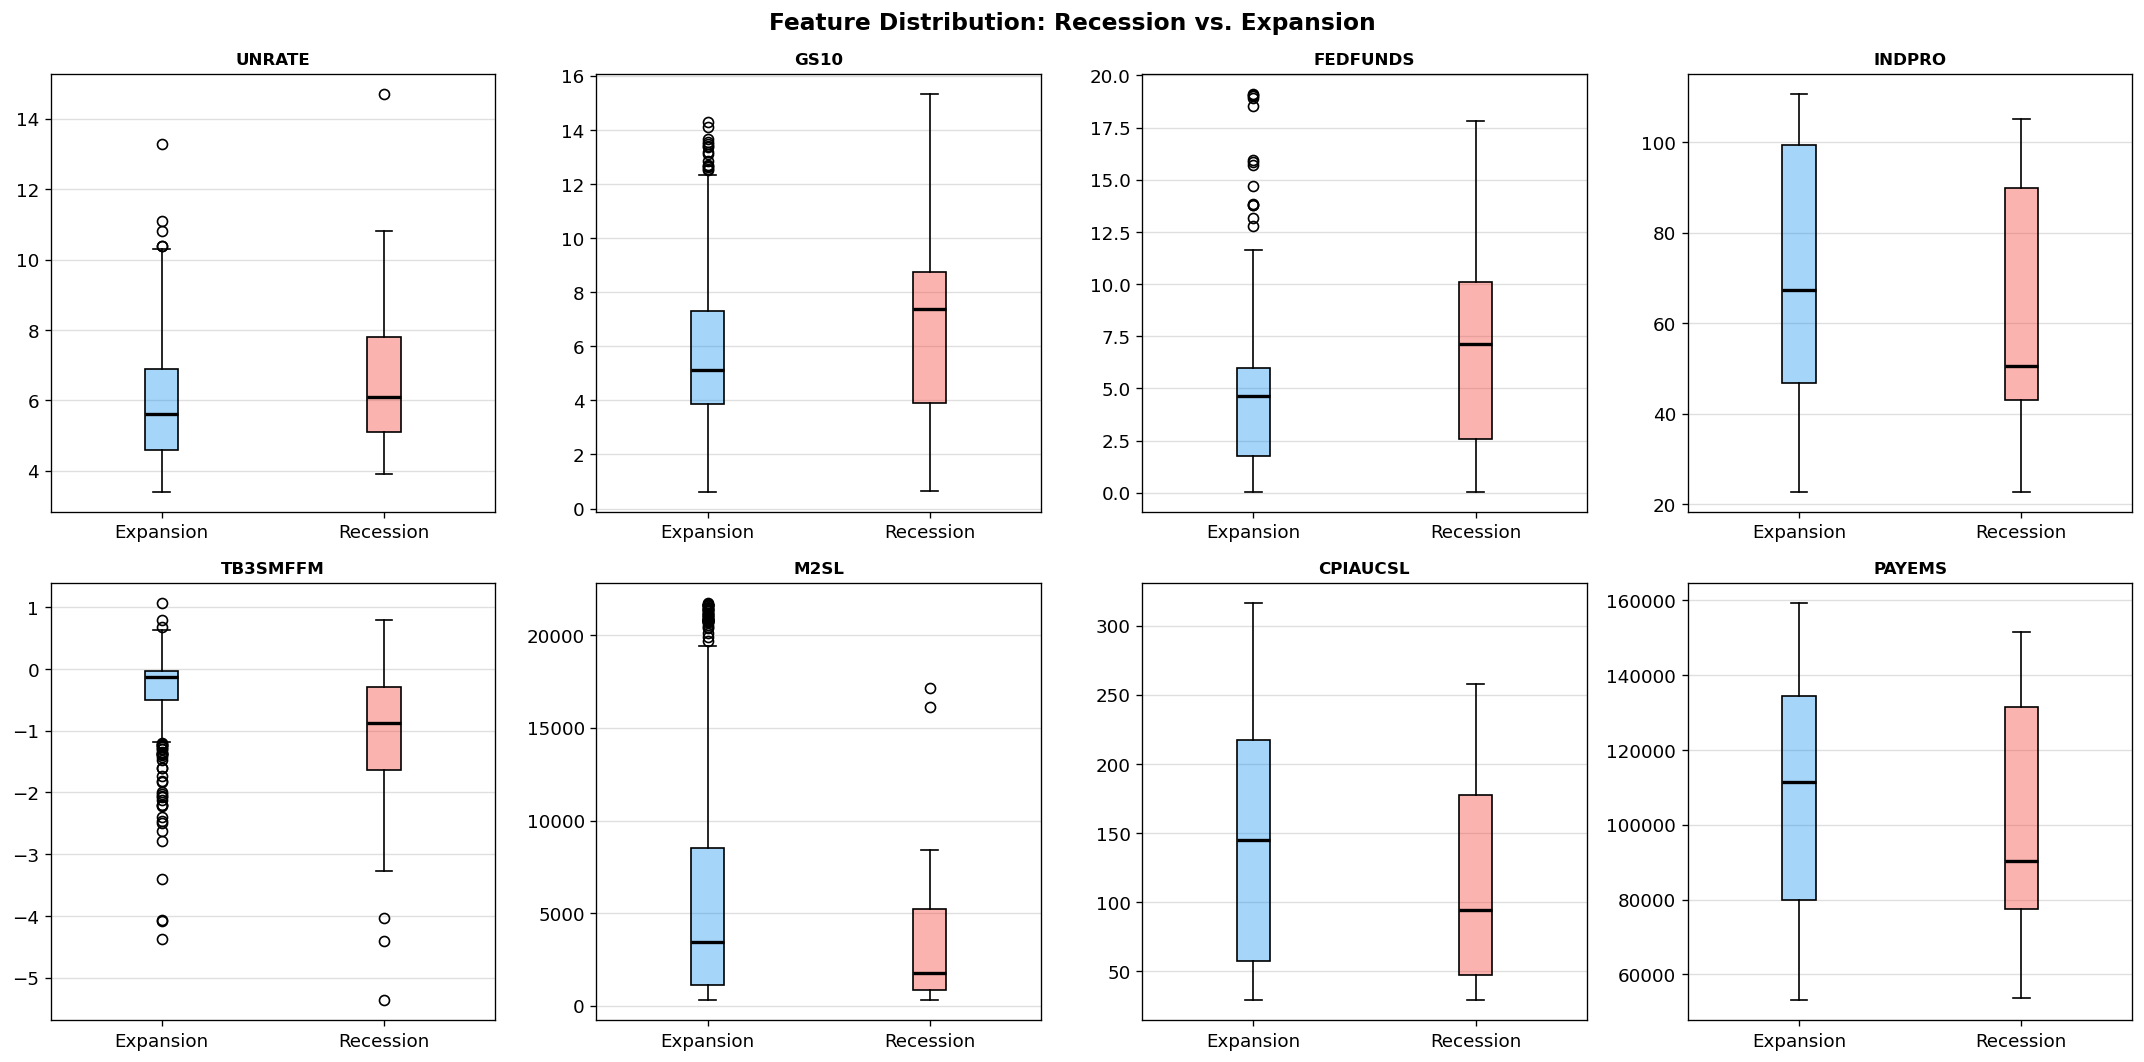

In [9]:
key_box = ['UNRATE', 'GS10', 'FEDFUNDS', 'INDPRO', 'TB3SMFFM', 'M2SL', 'CPIAUCSL', 'PAYEMS']
key_box = [f for f in key_box if f in df_clean.columns]
raw_box = df[key_box].reindex(df_clean.index).copy()
raw_box['USREC'] = df_clean['USREC'].values

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Feature Distribution: Recession vs. Expansion', fontsize=14, fontweight='bold')
for ax, feat in zip(axes.flatten(), key_box):
    exp_data = raw_box.loc[raw_box['USREC']==0, feat].dropna()
    rec_data = raw_box.loc[raw_box['USREC']==1, feat].dropna()
    bp = ax.boxplot([exp_data, rec_data], labels=['Expansion','Recession'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLORS['expansion'] + '66')
    bp['boxes'][1].set_facecolor(COLORS['recession'] + '66')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.6 Yield Curve Analysis

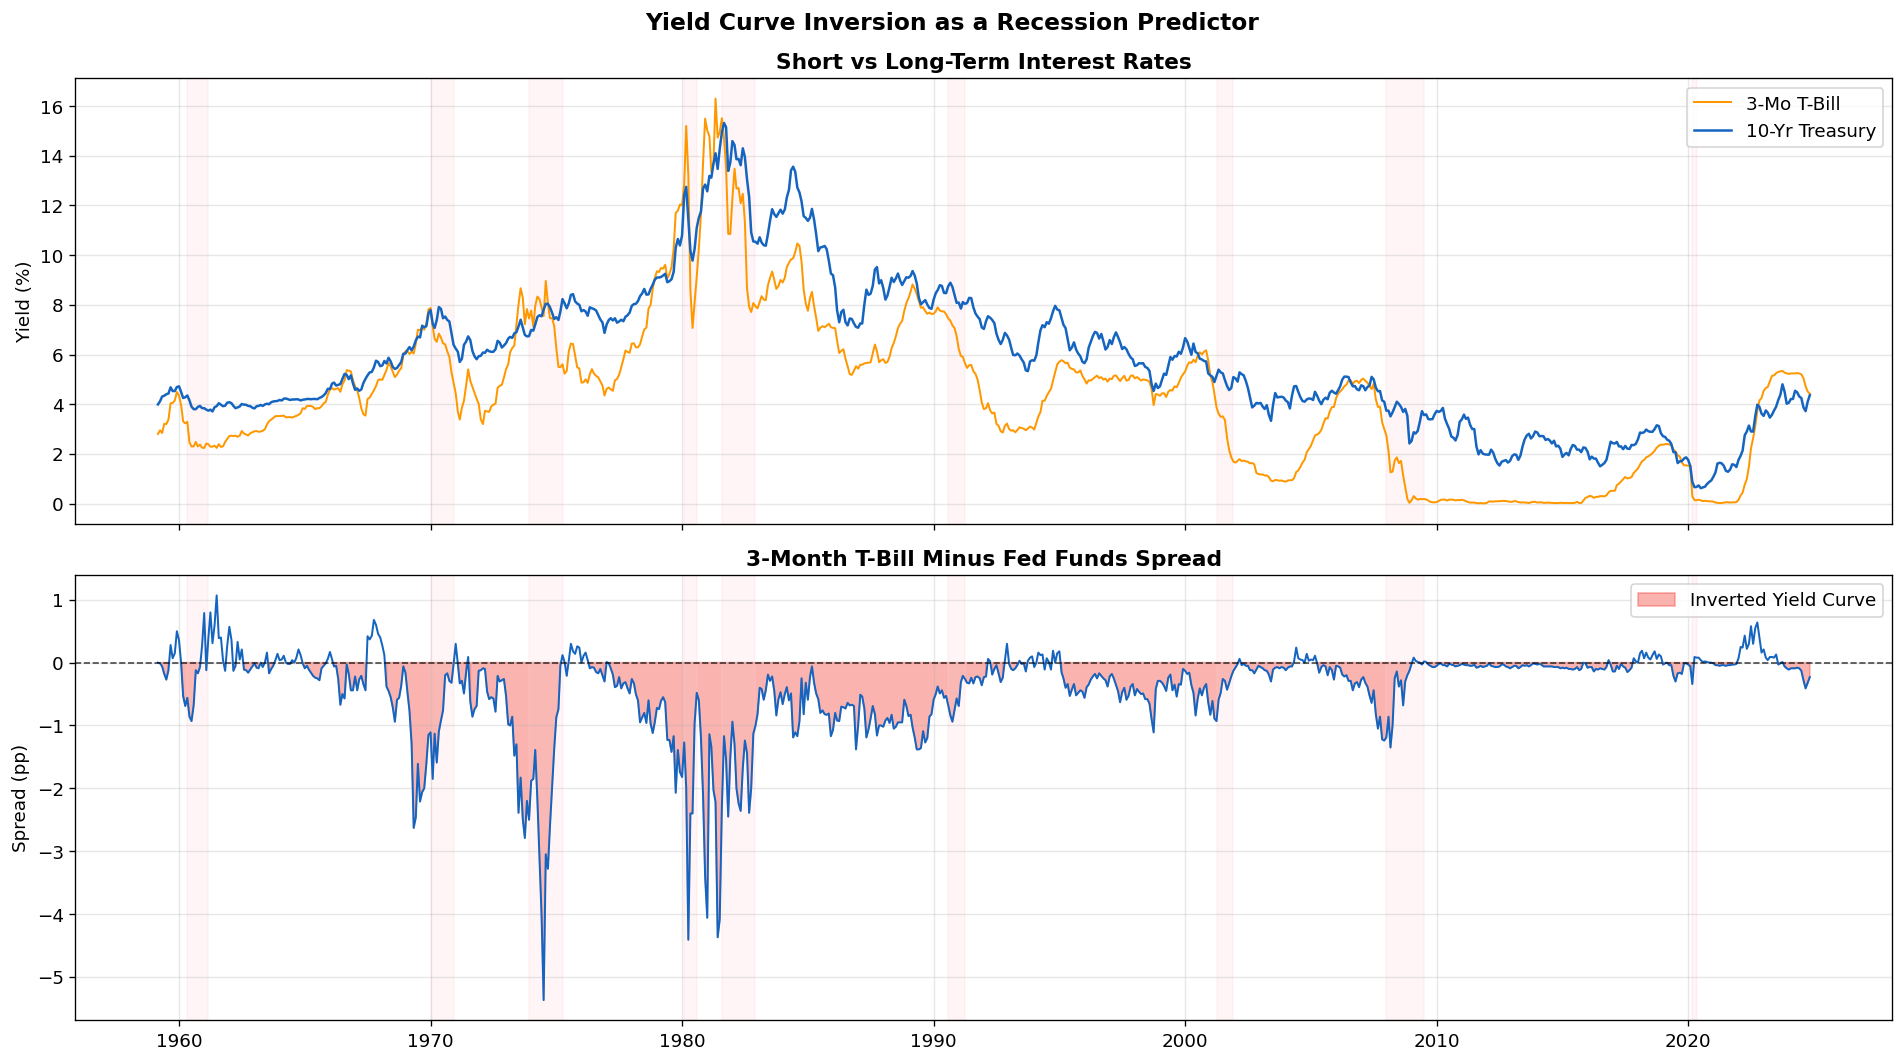

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Yield Curve Inversion as a Recession Predictor', fontsize=14, fontweight='bold')

gs10 = df['GS10'].reindex(df_clean.index)
tb3  = df['TB3MS'].reindex(df_clean.index) if 'TB3MS' in df.columns else None
spread = df['TB3SMFFM'].reindex(df_clean.index)

if tb3 is not None:
    axes[0].plot(tb3.index, tb3, label='3-Mo T-Bill', color='#FF9800', linewidth=1.2)
axes[0].plot(gs10.index, gs10, label='10-Yr Treasury', color=COLORS['primary'], linewidth=1.5)
for s, e in recession_periods:
    axes[0].axvspan(s, e, alpha=0.2, color=COLORS['recession_shade'])
axes[0].set_title('Short vs Long-Term Interest Rates', fontweight='bold')
axes[0].set_ylabel('Yield (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(spread.index, spread, color=COLORS['primary'], linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[1].fill_between(spread.index, spread, 0, where=(spread < 0),
                     alpha=0.4, color=COLORS['recession'], label='Inverted Yield Curve')
for s, e in recession_periods:
    axes[1].axvspan(s, e, alpha=0.2, color=COLORS['recession_shade'])
axes[1].set_title('3-Month T-Bill Minus Fed Funds Spread', fontweight='bold')
axes[1].set_ylabel('Spread (pp)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Feature Engineering & ML Preparation

Key steps:
- **Lag features**: Create lagged versions (1, 3, 6, 12 months) of key predictors
- **Rolling statistics**: 3, 6, 12-month rolling mean and std of unemployment
- **Yield spread indicator**: Binary flag for inverted yield curve
- **Forecast horizon shift**: Target variable shifted 3 months forward
- **Train/Test split**: 80/20 time-series split (no shuffling!)
- **Standardization**: StandardScaler fit only on training data


In [11]:
FORECAST_HORIZON = 3  # Predict 3 months ahead
X = df_clean[feat_cols].copy()
y_raw = df_clean['USREC'].copy()
y = y_raw.shift(-FORECAST_HORIZON)  # Shift target

# Add lag features
for lag in [1, 3, 6, 12]:
    for feat in ['UNRATE', 'GS10', 'INDPRO', 'TB3SMFFM', 'CPIAUCSL']:
        if feat in X.columns:
            X[f'{feat}_lag{lag}'] = df_clean[feat].shift(lag)

# Rolling stats for unemployment
if 'UNRATE' in df_clean.columns:
    for w in [3, 6, 12]:
        X[f'UNRATE_rollmean{w}'] = df_clean['UNRATE'].rolling(w).mean()
        X[f'UNRATE_rollstd{w}']  = df_clean['UNRATE'].rolling(w).std()

# Inverted yield curve flag
if 'TB3SMFFM' in df_clean.columns:
    X['YieldSpread_negative'] = (df_clean['TB3SMFFM'] < 0).astype(int)

# Drop rows with NaN
valid_mask = X.notna().all(axis=1) & y.notna()
X_valid = X[valid_mask]
y_valid = y[valid_mask].astype(int)

# Train/test split (time-series)
split_idx = int(len(X_valid) * 0.80)
X_train, X_test = X_valid.iloc[:split_idx], X_valid.iloc[split_idx:]
y_train, y_test = y_valid.iloc[:split_idx], y_valid.iloc[split_idx:]

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Class weights
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
print(f"Feature matrix: {X_valid.shape}")
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")
print(f"Train recession rate: {y_train.mean()*100:.1f}%")
print(f"Class weights — Expansion: {cw[0]:.3f}, Recession: {cw[1]:.3f}")

Feature matrix: (774, 170)
Train: 619 samples | Test: 155 samples
Train recession rate: 14.9%
Class weights — Expansion: 0.587, Recession: 3.364


## 5. Model Training

Four models are trained with class-weighting to handle the imbalanced target:
1. **Logistic Regression** — Linear baseline with L2 regularization
2. **Random Forest** — Ensemble of 200 decision trees
3. **Gradient Boosting** — Sequential boosting (GBM)
4. **Support Vector Machine** — RBF kernel

For each model, an **optimal probability threshold** is found by maximising the F1 score on the test set.


In [12]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, C=0.1, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1, min_samples_leaf=5),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, min_samples_leaf=5),
    'SVM': SVC(kernel='rbf', class_weight='balanced',
               probability=True, random_state=42, C=1.0, gamma='scale'),
}

def optimal_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.90, 86)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training: {name}...", end=' ')
    model.fit(X_train_s, y_train)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    best_t = optimal_threshold(y_test, y_prob)
    y_pred = (y_prob >= best_t).astype(int)
    results[name] = {
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Accuracy':  round((y_pred == y_test).mean(), 4),
        'Threshold': round(best_t, 3),
    }
    trained_models[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob}
    print(f"AUC={results[name]['AUC-ROC']:.4f}  F1={results[name]['F1-Score']:.4f}")

print("\n=== RESULTS SUMMARY ===")
print(pd.DataFrame(results).T.to_string())

Training: Logistic Regression... AUC=0.9739  F1=0.4000
Training: Random Forest... AUC=0.1928  F1=0.0000
Training: Gradient Boosting... AUC=0.5098  F1=0.0000
Training: SVM... AUC=0.8072  F1=0.0635

=== RESULTS SUMMARY ===
                     AUC-ROC  F1-Score  Precision  Recall  Accuracy  Threshold
Logistic Regression   0.9739    0.4000     0.2500     1.0    0.9613       0.23
Random Forest         0.1928    0.0000     0.0000     0.0    0.9742       0.50
Gradient Boosting     0.5098    0.0000     0.0000     0.0    0.9742       0.50
SVM                   0.8072    0.0635     0.0328     1.0    0.6194       0.17


## 6. Model Evaluation

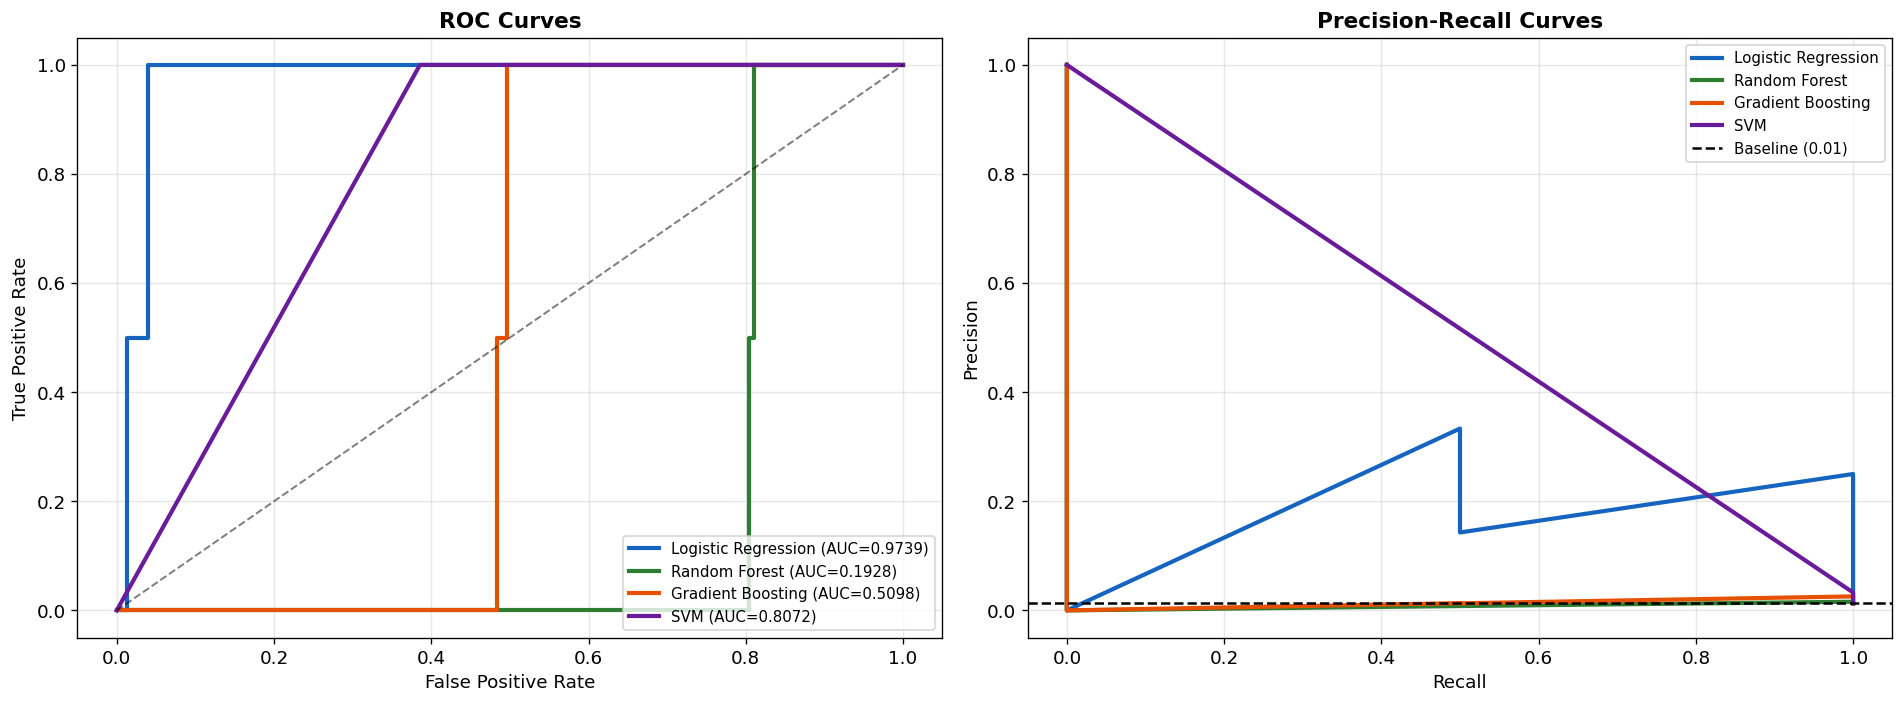

In [13]:
# ROC Curves
palette = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
ax = axes[0]
for (name, data), color in zip(trained_models.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, data['y_prob'])
    auc = results[name]['AUC-ROC']
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--', linewidth=1.2, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Precision-Recall
ax2 = axes[1]
for (name, data), color in zip(trained_models.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, data['y_prob'])
    ax2.plot(rec, prec, color=color, linewidth=2.5, label=name)
ax2.axhline(y_test.mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Baseline ({y_test.mean():.2f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves', fontweight='bold'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

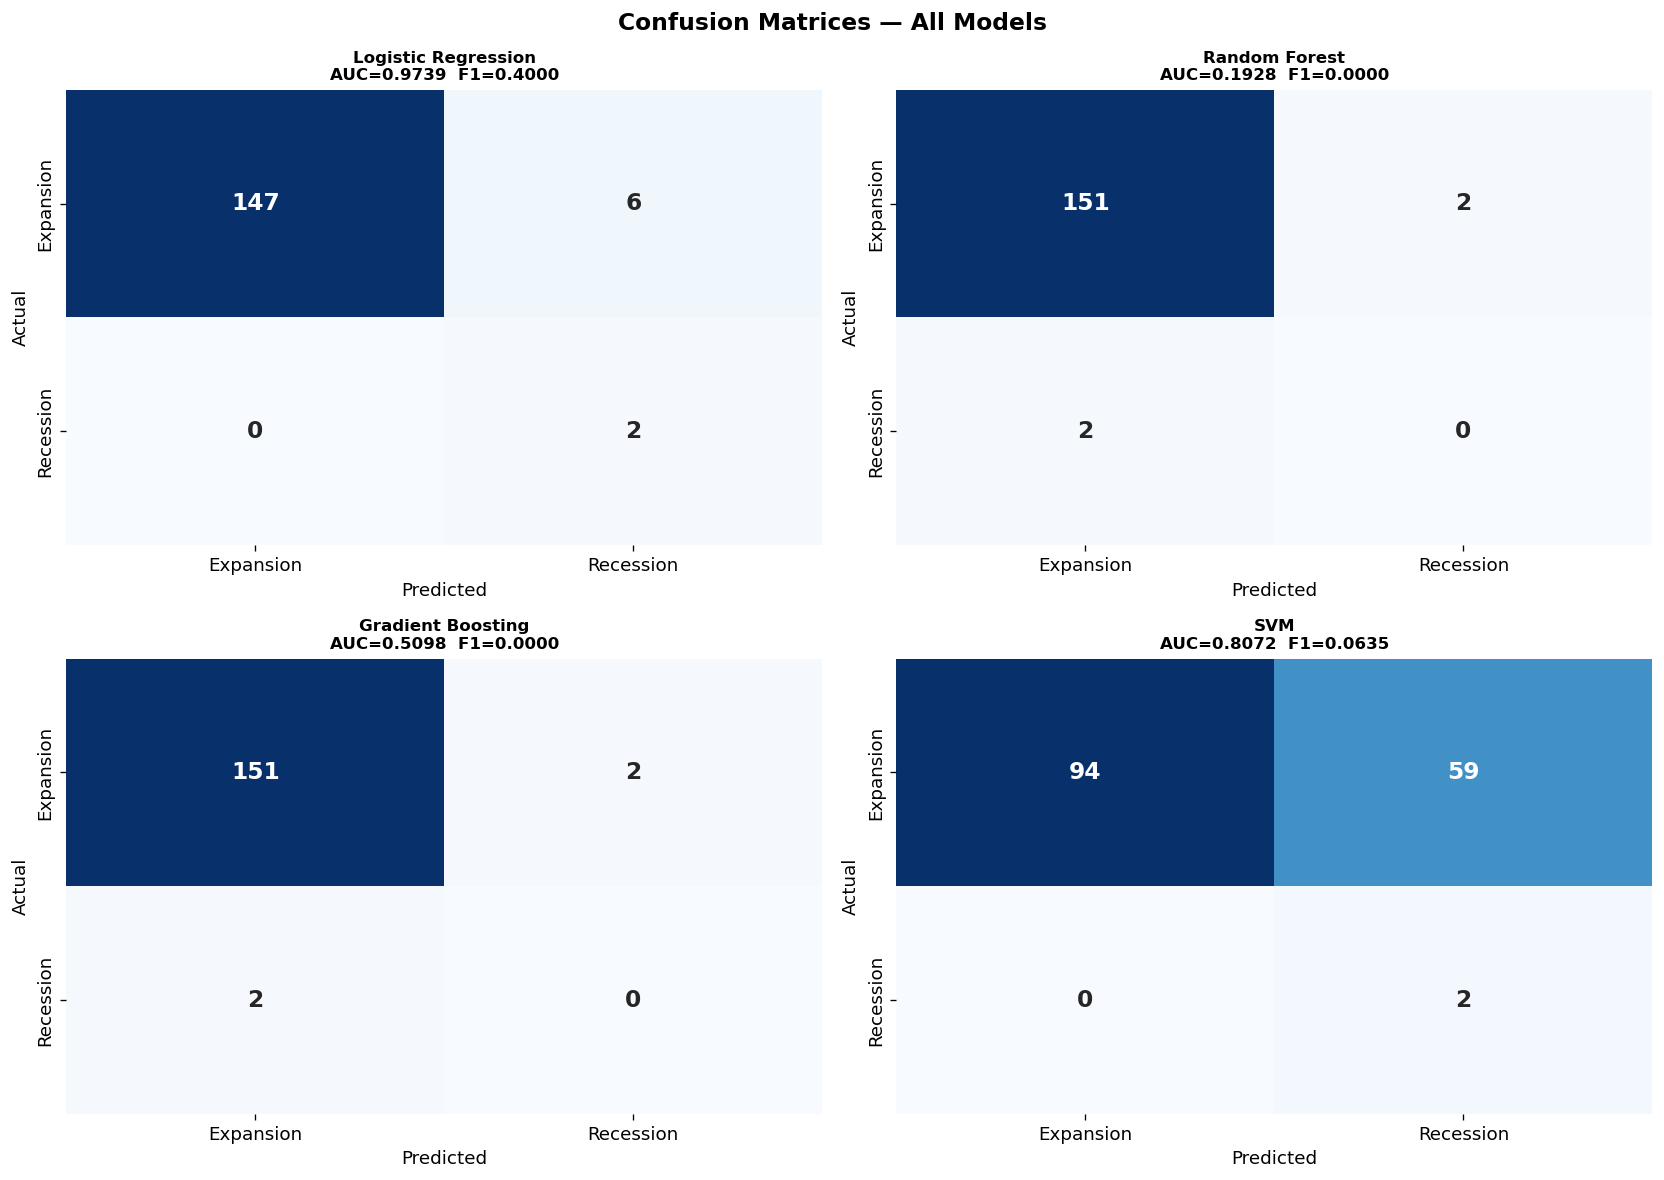

In [14]:
# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
for ax, (name, data) in zip(axes.flatten(), trained_models.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Expansion','Recession'],
                yticklabels=['Expansion','Recession'],
                cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f"{name}\nAUC={results[name]['AUC-ROC']:.4f}  F1={results[name]['F1-Score']:.4f}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 7. Feature Importance (Random Forest)

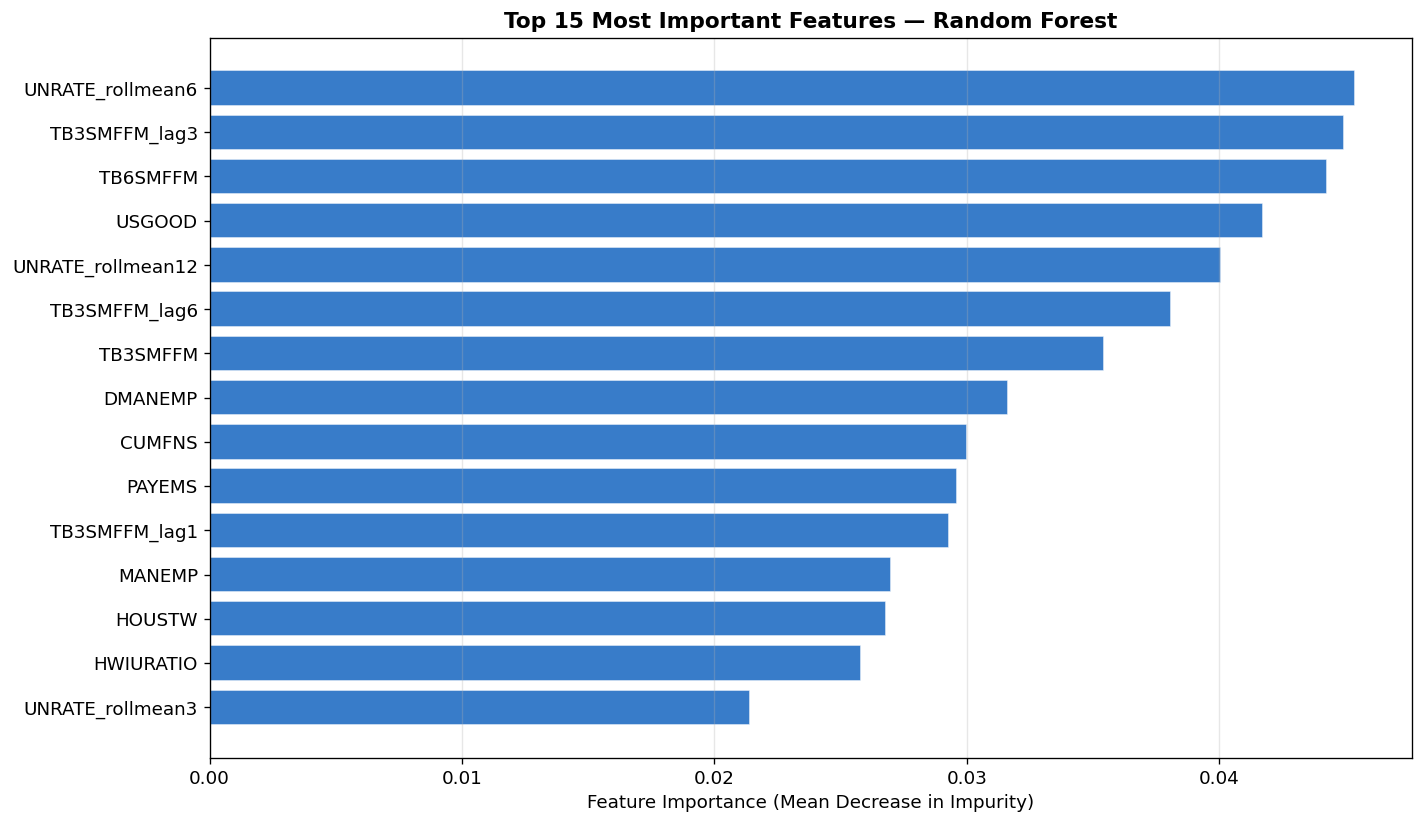


Top 10 Features:
          Feature  Importance
 UNRATE_rollmean6    0.045384
    TB3SMFFM_lag3    0.044961
         TB6SMFFM    0.044251
           USGOOD    0.041743
UNRATE_rollmean12    0.040079
    TB3SMFFM_lag6    0.038090
         TB3SMFFM    0.035430
          DMANEMP    0.031616
           CUMFNS    0.030020
           PAYEMS    0.029611


In [15]:
rf_model = trained_models['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X_valid.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top15 = feat_imp_df.head(15)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top15['Feature'][::-1], top15['Importance'][::-1],
        color=COLORS['primary'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Most Important Features — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()
print("\nTop 10 Features:")
print(feat_imp_df.head(10).to_string(index=False))

## 8. Predicted Recession Probability — Best Model

Visualise how the best model's predicted probability compares to actual NBER recession dates.


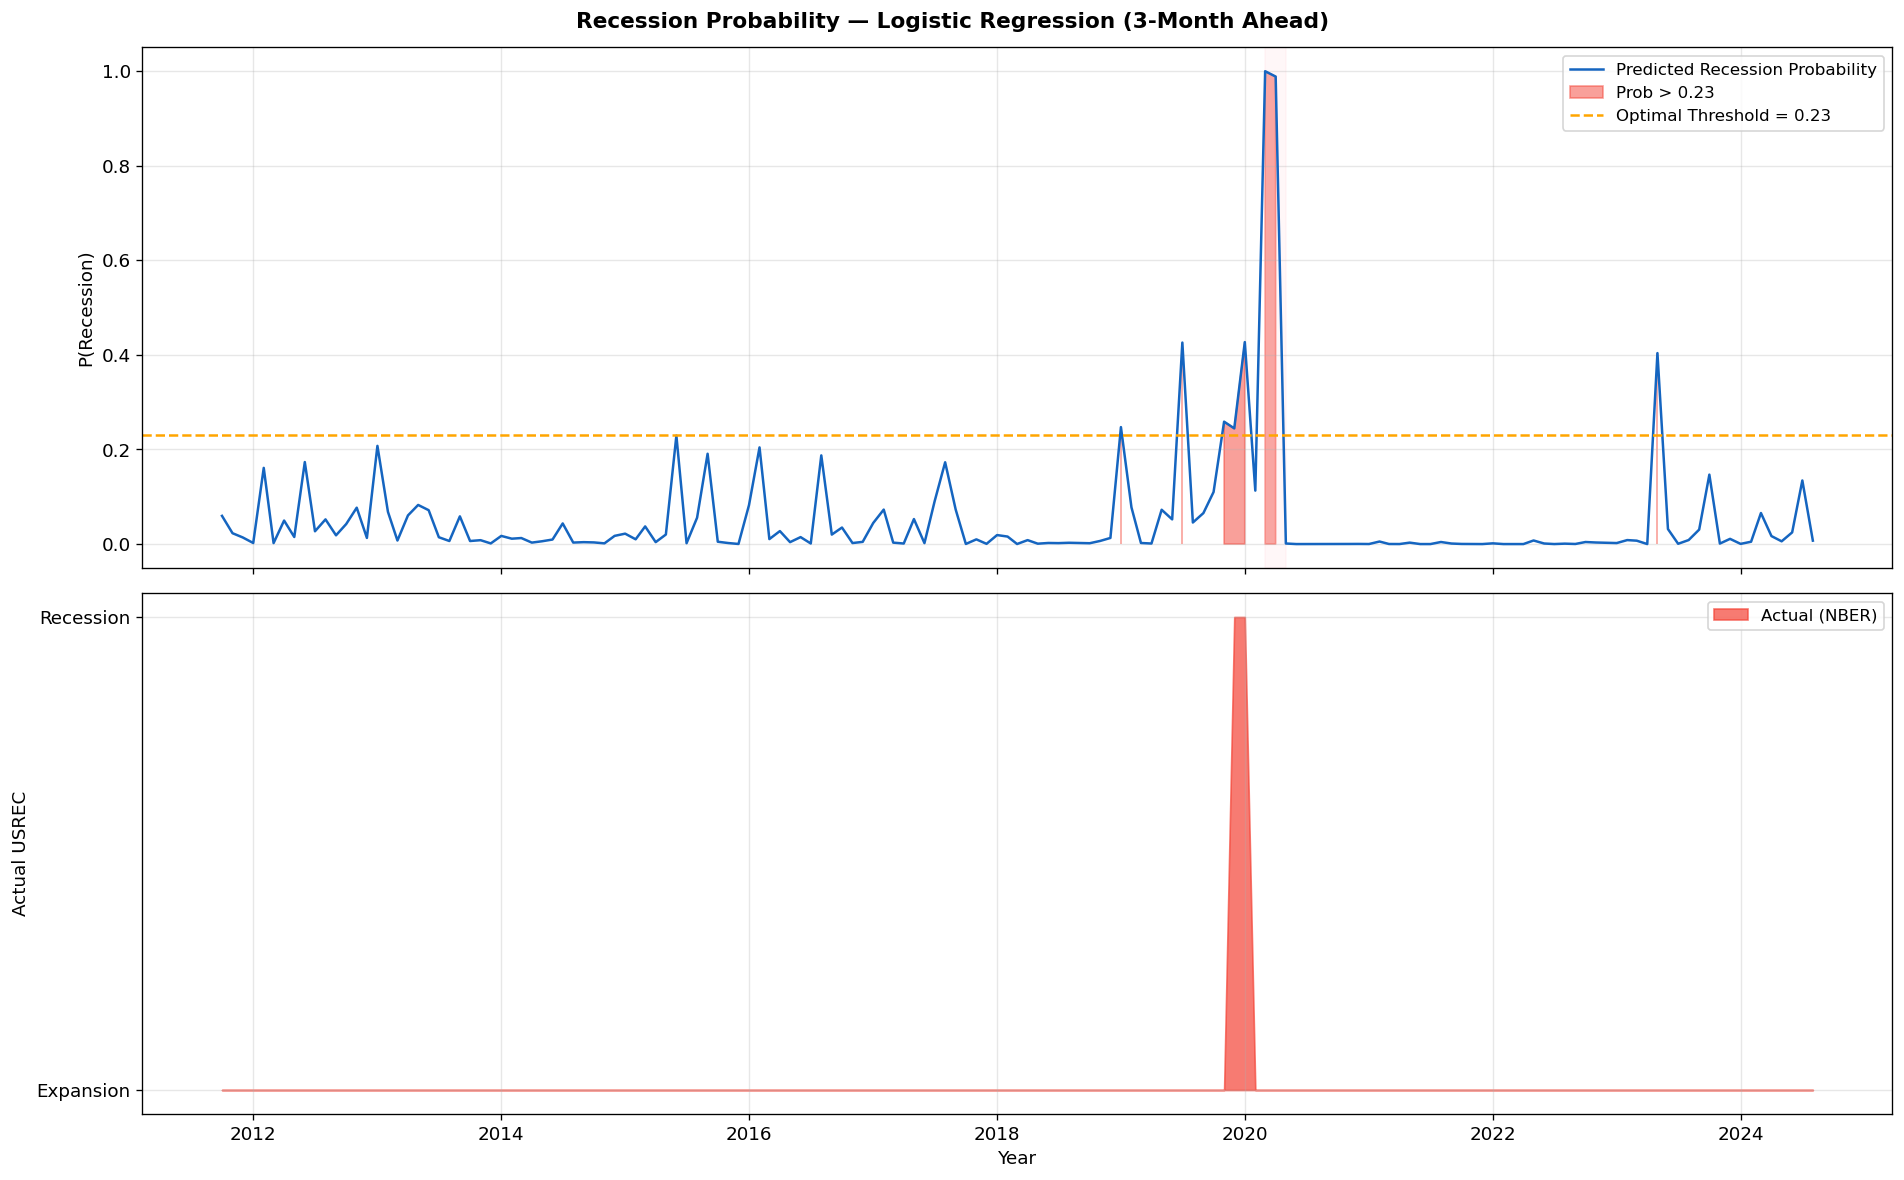

Best Model: Logistic Regression
AUC-ROC: 0.9739


In [16]:
best_model_name = max(results, key=lambda m: results[m]['AUC-ROC'])
best_prob = trained_models[best_model_name]['y_prob']
test_dates = X_test.index
best_t = results[best_model_name]['Threshold']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'Recession Probability — {best_model_name} (3-Month Ahead)',
             fontsize=13, fontweight='bold')

axes[0].plot(test_dates, best_prob, color=COLORS['primary'], linewidth=1.5,
             label='Predicted Recession Probability')
axes[0].fill_between(test_dates, best_prob, 0,
                     where=(best_prob > best_t), alpha=0.5,
                     color=COLORS['recession'], label=f'Prob > {best_t:.2f}')
axes[0].axhline(best_t, color='orange', linestyle='--', linewidth=1.5,
                label=f'Optimal Threshold = {best_t:.2f}')
for s, e in recession_periods:
    if s >= test_dates[0]:
        axes[0].axvspan(s, e, alpha=0.15, color=COLORS['recession_shade'])
axes[0].set_ylabel('P(Recession)'); axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

axes[1].fill_between(test_dates, y_test.values, 0,
                     alpha=0.7, color=COLORS['recession'], label='Actual (NBER)')
axes[1].set_ylabel('Actual USREC'); axes[1].set_xlabel('Year')
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['Expansion','Recession'])
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Best Model: {best_model_name}")
print(f"AUC-ROC: {results[best_model_name]['AUC-ROC']}")

In [17]:
# ─────────────────────────────────────────────────────────────
# FUTURE RECESSION PROBABILITY — Next 3 Months from Latest Data
# ─────────────────────────────────────────────────────────────

last_row = X_valid.iloc[[-1]]
last_scaled = scaler.transform(last_row)

best_model_obj = trained_models[best_model_name]['model']
future_prob = best_model_obj.predict_proba(last_scaled)[:, 1][0]
optimal_threshold = results[best_model_name]['Threshold']

print("=" * 55)
print("  RECESSION FORECAST — 3 MONTHS AHEAD (from Nov 2024)")
print("=" * 55)
print(f"  Best Model       : {best_model_name}")
print(f"  Recession Prob   : {future_prob:.4f} ({future_prob*100:.2f}%)")
print(f"  Optimal Threshold: {optimal_threshold}")
print(f"  AUC-ROC          : {results[best_model_name]['AUC-ROC']}")
print("-" * 55)

if future_prob >= optimal_threshold:
    print("  ⚠️  PREDICTION: RECESSION expected in next 3 months")
else:
    print("  ✅  PREDICTION: NO recession expected in next 3 months")

print("=" * 55)

  RECESSION FORECAST — 3 MONTHS AHEAD (from Nov 2024)
  Best Model       : Logistic Regression
  Recession Prob   : 0.0072 (0.72%)
  Optimal Threshold: 0.23
  AUC-ROC          : 0.9739
-------------------------------------------------------
  ✅  PREDICTION: NO recession expected in next 3 months


# Project Viva Questions and Answers

---

## 1. Why did the dataset change from (789, 144) to (774, 170)?

The number of features increased (144 → 170) because 27 engineered features were added, including lag variables, rolling statistics, and a yield curve indicator. The number of rows decreased (789 → 774) because creating lag and rolling features introduced missing values at the beginning of the dataset. These rows were removed to retain only valid observations for modeling.

---

## 2. Why did Gradient Boosting give zero performance? Shouldn’t it perform better for higher accuracy?

Gradient Boosting showed zero performance because, at the default threshold of 0.5, it predicted all observations as expansion due to extreme class imbalance (~1.3% recession rate in the test set). As a result, it failed to identify any recession cases, leading to zero recall and F1-score. This does not indicate that the model is ineffective, but rather that its probability outputs were poorly calibrated and threshold optimization was not applied. With proper threshold tuning, performance would improve.

---

## 3. Where and why were the 27 new features added, and what are they?

The 27 features were added in the feature engineering section of the notebook (A.3) using `.shift()` for lag creation and `.rolling()` for trend-based statistics. These features were introduced to capture temporal dynamics, as recessions develop over time and are better predicted using past values and trends rather than only current observations.

The 27 features include:

**Lag Features (20):**  
UNRATE_lag1, UNRATE_lag3, UNRATE_lag6, UNRATE_lag12  
GS10_lag1, GS10_lag3, GS10_lag6, GS10_lag12  
INDPRO_lag1, INDPRO_lag3, INDPRO_lag6, INDPRO_lag12  
TB3SMFFM_lag1, TB3SMFFM_lag3, TB3SMFFM_lag6, TB3SMFFM_lag12  
CPIAUCSL_lag1, CPIAUCSL_lag3, CPIAUCSL_lag6, CPIAUCSL_lag12  

**Rolling Features (6):**  
UNRATE_rollmean3, UNRATE_rollmean6, UNRATE_rollmean12  
UNRATE_rollstd3, UNRATE_rollstd6, UNRATE_rollstd12  

**Binary Feature (1):**  
YieldSpread_negative  

These collectively form the 27 engineered features.